# 라이브러리 및 기본 설정

In [1]:
# ─────────────────────────────────────────────
# 라이브러리 및 기본 설정
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore') # 모든 경고를 무시하려면 이 한 줄이면 됩니다.


# 데이터 로드 및 전처리 함수 정의

In [105]:
# ─────────────────────────────────────────────
# 데이터 로드 및 전처리 함수 정의
# ─────────────────────────────────────────────
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]  # s_22 제외
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
ID_COL = 'unit_nr'
CYCLE_COL = 'time_cycles'

COL_NAMES = [ID_COL, CYCLE_COL] + SETTING_COLS + SENSOR_COLS


def load_data(train_path: str, test_path: str, rul_path: str):
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    df_rul = pd.read_csv(rul_path)

    print(f"[load_data] train={df_train.shape} | test={df_test.shape} | rul={df_rul.shape}")
    return df_train, df_test, df_rul


def select_sensors(df_train: pd.DataFrame, df_test: pd.DataFrame, exclude_sensors: list = None) -> tuple:
    if exclude_sensors is None:
        exclude_sensors = []

    selected = [s for s in SENSOR_COLS if s not in exclude_sensors]
    keep_cols = [ID_COL, CYCLE_COL] + selected

    df_train = df_train[keep_cols].copy()
    df_test = df_test[keep_cols].copy()

    print(f"[select_sensors] 선택된 센서 수: {len(selected)} | 제외: {exclude_sensors}")
    return df_train, df_test, selected


def remove_noise(df_train: pd.DataFrame, df_test: pd.DataFrame, selected: list, sigma: float = 2.0) -> tuple:
    def _apply(df):
        df = df.copy()
        for unit_id in df[ID_COL].unique():
            mask = df[ID_COL] == unit_id
            for col in selected:
                df.loc[mask, col] = gaussian_filter1d(df.loc[mask, col].values, sigma=sigma)
        return df

    df_train = _apply(df_train)
    df_test = _apply(df_test)

    print(f"[remove_noise] gaussian sigma={sigma} 적용 완료")
    return df_train, df_test


def normalize(df_train: pd.DataFrame, df_test: pd.DataFrame, selected: list, method: str = 'minmax') -> tuple:
    if method == 'minmax':
        scaler = MinMaxScaler()
    elif method == 'standard':
        scaler = StandardScaler()
    else:
        raise ValueError(f"지원하지 않는 정규화 방법: {method} | 선택 가능: 'minmax', 'standard'")

    df_train = df_train.copy()
    df_test = df_test.copy()

    df_train[selected] = scaler.fit_transform(df_train[selected])
    df_test[selected] = scaler.transform(df_test[selected])

    print(f"[normalize] method={method} 적용 완료")
    return df_train, df_test, scaler


def create_rul_label(df_train: pd.DataFrame, rul_cap: int = 125) -> pd.DataFrame:
    df_train = df_train.copy()
    df_train['RUL'] = (
        df_train.groupby(ID_COL)[CYCLE_COL]
        .transform('max') - df_train[CYCLE_COL]
    )
    df_train['RUL'] = df_train['RUL'].clip(upper=rul_cap)

    print(f"[create_rul_label] RUL cap={rul_cap} | RUL range: {df_train['RUL'].min()} ~ {df_train['RUL'].max()}")
    return df_train


def create_windows(df: pd.DataFrame, selected: list, window_size: int = 30) -> tuple:
    X_list, y_list = [], []

    for unit_id in df[ID_COL].unique():
        unit_df = df[df[ID_COL] == unit_id].reset_index(drop=True)
        values = unit_df[selected].values
        labels = unit_df['RUL'].values

        for i in range(len(unit_df) - window_size + 1):
            X_list.append(values[i: i + window_size].flatten())
            y_list.append(labels[i + window_size - 1])

    X = np.array(X_list)
    y = np.array(y_list)

    print(f"[create_windows] train window X={X.shape} | y={y.shape}")
    return X, y


def create_windows_test(df_test: pd.DataFrame, df_rul: pd.DataFrame, selected: list, window_size: int = 30) -> tuple:
    X_list = []

    for unit_id in df_test[ID_COL].unique():
        unit_df = df_test[df_test[ID_COL] == unit_id].reset_index(drop=True)
        values = unit_df[selected].values

        if len(unit_df) >= window_size:
            window = values[-window_size:].flatten()
        else:
            pad = np.zeros((window_size - len(unit_df), len(selected)))
            window = np.vstack([pad, values]).flatten()

        X_list.append(window)

    X = np.array(X_list)
    y = df_rul['RUL'].values

    print(f"[create_windows_test] test window X={X.shape} | y={y.shape}")
    return X, y

def build_ml_dataset(df_train, df_test, df_rul, exclude_sensors=None, 
                     sigma=2.0, norm_method='minmax', rul_cap=125, window_size=5):
    
    # [1] 센서 선택 및 노이즈 제거 (가우시안 시그마/알파 반영)
    df_tr_p, df_te_p, selected = select_sensors(df_train, df_test, exclude_sensors)
    df_tr_p, df_te_p = remove_noise(df_tr_p, df_te_p, selected, sigma=sigma)
    
    # [2] 정규화 (MinMax 등 방식 반영)
    df_tr_p, df_te_p, _ = normalize(df_tr_p, df_te_p, selected, method=norm_method)
    
    # [3] 파생 변수 생성 (Rolling Mean으로 추세 추가)
    final_features = selected.copy()
    for s in selected:
        col_name = f'{s}_rolling'
        df_tr_p[col_name] = df_tr_p.groupby(ID_COL)[s].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
        df_te_p[col_name] = df_te_p.groupby(ID_COL)[s].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
        final_features.append(col_name)
    
    # [4] RUL 라벨 생성 (RUL Cap 반영)
    df_tr_p = create_rul_label(df_tr_p, rul_cap=rul_cap)

    # [5] 엔진 ID 기준 8:1:1 분할 (시계열 연속성 보존)
    unit_ids = df_tr_p[ID_COL].unique()
    np.random.seed(42)
    np.random.shuffle(unit_ids)
    
    train_split = int(len(unit_ids) * 0.8)
    val_split = int(len(unit_ids) * 0.9)
    
    tr_ids = unit_ids[:train_split]
    val_ids = unit_ids[train_split:val_split]
    te_int_ids = unit_ids[val_split:]
    
    # [6] 각 세트별 데이터 생성
    train_df = df_tr_p[df_tr_p[ID_COL].isin(tr_ids)]
    val_df   = df_tr_p[df_tr_p[ID_COL].isin(val_ids)]
    te_int_df = df_tr_p[df_tr_p[ID_COL].isin(te_int_ids)]
    
    X_tr, y_tr = train_df[final_features].values, train_df['RUL'].values
    X_val, y_val = val_df[final_features].values, val_df['RUL'].values
    X_te_int, y_te_int = te_int_df[final_features].values, te_int_df['RUL'].values
    
    # [7] Final Test (NASA TEST1 - 엔진별 마지막 100행)
    # id(unit_nr)별로 마지막 사이클 행의 인덱스를 추출
    test_last_idx = df_te_p.groupby(ID_COL)[CYCLE_COL].idxmax().values
    X_te_fin = df_te_p.loc[test_last_idx, final_features].values
    y_te_fin = df_rul['RUL'].values
    
    return X_tr, X_val, X_te_int, X_te_fin, y_tr, y_val, y_te_int, y_te_fin, final_features


def build_deep_dataset(X_tr, X_val, X_te_int, X_te_fin, window_size, feature_count):
    """
    ML 데이터를 CNN용 3D 텐서로 변환: (Samples, Window_Size, Features)
    """
    # CNN 입력을 위해 reshape (데이터 개수, 윈도우 크기, 센서 수)
    # build_ml_dataset에서 이미 window_size만큼의 시계열이 반영된 구조라 가정
    X_tr_deep = X_tr.values.reshape(-1, window_size, feature_count)
    X_val_deep = X_val.values.reshape(-1, window_size, feature_count)
    X_te_int_deep = X_te_int.values.reshape(-1, window_size, feature_count)
    X_te_fin_deep = X_te_fin.values.reshape(-1, window_size, feature_count)
    
    print(f"✅ Deep Learning Shape 변환 완료")
    print(f"   - Train: {X_tr_deep.shape}")
    print(f"   - Final Test: {X_te_fin_deep.shape}")
    
    return X_tr_deep, X_val_deep, X_te_int_deep, X_te_fin_deep


def split_ml_data(df_train_p: pd.DataFrame, df_test_p: pd.DataFrame, df_rul: pd.DataFrame, 
                  selected: list) -> tuple:
    """
    X_train: df_train에서 엔진별 마지막 행(100개)을 제외한 데이터
    y_train: X_train에 대응하는 RUL
    X_test: test_FD001 데이터 전체 (전처리 완료된 상태)
    y_test: RUL_FD001 정답 데이터 (100개)
    """
    
    # 1. Train 데이터에서 엔진별 마지막 행(Max Cycle) 100개 인덱스 추출
    last_indices = df_train_p.groupby(ID_COL)[CYCLE_COL].idxmax()
    
    # 2. Train 분리: 마지막 행 100개를 제외한 나머지를 학습용으로 사용
    # (참고: 필요하다면 제외한 100개를 별도의 val 셋으로 활용 가능합니다)
    df_train_ml = df_train_p.drop(last_indices)
    
    X_train = df_train_ml[selected].values
    y_train = df_train_ml['RUL'].values
    
    # 3. Test: test_FD001의 전체 데이터를 머신러닝 입력용으로 사용
    # 엔진별 마지막 시점 100개만 뽑아서 정답(y_test)과 비교하기 위해 별도 처리
    test_last_indices = df_test_p.groupby(ID_COL)[CYCLE_COL].idxmax()
    X_test = df_test_p.loc[test_last_indices, selected].values
    
    # 4. 정답지
    y_test = df_rul['RUL'].values
    
    print(f"[split_ml_data] 완료")
    print(f"  X_train(전체-100): {X_train.shape} | y_train: {y_train.shape}")
    print(f"  X_test(엔진별 마지막 시점): {X_test.shape} | y_test: {y_test.shape}")
    
    return X_train, X_test, y_train, y_test

def split_data(X: np.ndarray, y: np.ndarray, val_size: float = 0.2, random_state: int = 42) -> tuple:
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=val_size, random_state=random_state)
    print(f"[split_data] X_train={X_train.shape} | X_val={X_val.shape}")
    return X_train, X_val, y_train, y_val


def build_dataset(df_train: pd.DataFrame, df_test: pd.DataFrame, df_rul: pd.DataFrame,
                  exclude_sensors: list = None, sigma: float = 2.0, norm_method: str = 'minmax',
                  rul_cap: int = 125, window_size: int = 30, val_size: float = 0.2) -> tuple:
    
    # 1. 전처리 (센서 선택, 노이즈 제거, 정규화)
    df_train, df_test, selected = select_sensors(df_train, df_test, exclude_sensors)
    df_train, df_test = remove_noise(df_train, df_test, selected, sigma=sigma)
    df_train, df_test, scaler = normalize(df_train, df_test, selected, method=norm_method)
    
    # 2. RUL 라벨 생성
    df_train = create_rul_label(df_train, rul_cap=rul_cap)

    # ──────────────────────────────────────────────────────────
    # [핵심 수정] 윈도우 생성 전, 엔진 ID 단위로 Train/Val 분리
    # ──────────────────────────────────────────────────────────
    import numpy as np
    all_ids = df_train['id'].unique()
    np.random.seed(42) # 결과 재현을 위해 고정
    np.random.shuffle(all_ids)
    
    # 설정하신 val_size(0.2)만큼 엔진을 나눔 (100개 중 20개 엔진을 검증용으로)
    val_count = int(len(all_ids) * val_size)
    val_ids = all_ids[:val_count]
    train_ids = all_ids[val_count:]
    
    # 엔진 ID 기준으로 데이터프레임 쪼개기
    df_val_final = df_train[df_train['id'].isin(val_ids)].copy()
    df_train_final = df_train[df_train['id'].isin(train_ids)].copy()
    
    # 3. 쪼개진 데이터프레임에서 각각 윈도우 생성 (서로 절대 안 섞임!)
    X_train, y_train = create_windows(df_train_final, selected, window_size=window_size)
    X_val, y_val = create_windows(df_val_final, selected, window_size=window_size)
    
    # 4. 테스트 셋 윈도우 생성
    X_te, y_te = create_windows_test(df_test, df_rul, selected, window_size=window_size)
    # ──────────────────────────────────────────────────────────

    print(f"\n[build_dataset] 완료 (엔진 ID 격리 적용)")
    print(f"  - Train 엔진: {len(train_ids)}개, Val 엔진: {len(val_ids)}개")
    print(f"  - X_train={X_train.shape} | X_val={X_val.shape} | X_test={X_te.shape}")
    
    return X_train, X_val, X_te, y_train, y_val, y_te, selected


In [3]:
# ─────────────────────────────────────────────
# Cell 3: 모델 평가 함수 정의
# ─────────────────────────────────────────────
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error"""
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    NASA CMAPSS Scoring Function
    - d < 0 (과대 예측): exp(-d/13) - 1
    - d >= 0 (과소 예측): exp(d/10) - 1
    """
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(np.sum(s))


# XGBRegressor 모델 학습 함수 정의

In [ ]:
def train_xgb(X_train, y_train, X_val, y_val, 
              n_estimators=1000, 
              learning_rate=0.03,  # 조금 더 정교하게 학습
              max_depth=5,         # 너무 깊지 않게 조절 (과적합 방지)
              subsample=0.8,       # 데이터의 80%만 무작위로 사용하여 학습
              colsample_bytree=0.8,# 센서의 80%만 사용하여 학습
              log_interval=100):
    
    # 모델 정의 시 튜닝값 주입
    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1,
        eval_metric='rmse',
        early_stopping_rounds=50 # 50번 동안 성적이 안 좋아지면 자동 멈춤
    )

    # 학습
    model.fit(
        X_train, y_train, 
        eval_set=[(X_train, y_train), (X_val, y_val)], 
        verbose=False
    )
    
    print(f"\n[train_xgb] 튜닝 적용 완료 (Depth: {max_depth}, LR: {learning_rate})")
    return model

# LGBMRegressor 모델 학습 함수 정의

In [57]:
# [LGBM 함수 정의]
def train_lgbm(X_train, y_train, X_val, y_val, 
               n_estimators=1000, learning_rate=0.01, num_leaves=10, 
               max_depth=3, subsample=0.6, colsample_bytree=0.6, log_interval=50):
    
    # 에러 방지를 위해 필요한 함수들을 여기서 직접 임포트합니다.
    from lightgbm import LGBMRegressor, log_evaluation, early_stopping
    
    model = LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1,
        importance_type='gain'
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_metric='rmse',
        callbacks=[
            log_evaluation(log_interval),
            # 50번 동안 점수가 안 좋아지면 거기서 멈춤! (과적합 방지 핵심)
            early_stopping(stopping_rounds=50) 
        ]
    )
    
    print(f"\n[train_lgbm] 조기 종료 및 튜닝 적용 완료")
    return model

# RandomForestRegressor 모델 학습 함수 정의

In [60]:
from sklearn.ensemble import RandomForestRegressor

def train_rf(X_train, y_train, n_estimators=200, max_depth=10, 
             min_samples_leaf=5, max_features='sqrt'):
    """
    Random Forest Regressor 훈련 함수
    - n_estimators: 결정 트리 개수 (많을수록 안정적이나 속도 저하)
    - max_depth: 트리의 최대 깊이 (과적합 방지 핵심 파라미터)
    - min_samples_leaf: 리프 노드가 되기 위한 최소 샘플 수
    - max_features: 최적의 분할을 찾기 위해 고려할 피처 수
    """
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1,  # 모든 CPU 코어 사용
        verbose=0
    )

    print(f"[Random Forest] 학습 시작 (n_estimators={n_estimators}, max_depth={max_depth})...")
    model.fit(X_train, y_train)
    print(f"[train_rf] 학습 및 튜닝 적용 완료")
    
    return model

# def train_cnn

In [72]:
import torch.nn as nn
import torch.optim as optim

# [모델 정의] 1D-CNN 구조
class CNN1D(nn.Module):
    def __init__(self, input_channels, window_size):
        super(CNN1D, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten()
        )
        # 윈도우 5 기준: Conv(4) -> Pool(2). 32필터 * 2 = 64
        self.fc_layer = nn.Sequential(
            nn.Linear(32 * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        x = self.conv_layer(x)
        return self.fc_layer(x)

# [학습 함수] 최적의 모델 보존(Best Model Saving) 포함
def train_pytorch_cnn(model, tr_loader, val_loader, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf')
    
    print("🚀 CNN 학습 시작...")
    for epoch in range(epochs):
        model.train()
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
        
        # 검증 단계
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for vx, vy in val_loader:
                v_loss += criterion(model(vx), vy).item()
        
        avg_v_loss = v_loss / len(val_loader)
        
        # 10회마다 결과 출력
        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Val RMSE: {np.sqrt(avg_v_loss):.4f}")
        
        # 최적 모델 저장
        if avg_v_loss < best_loss:
            best_loss = avg_v_loss
            torch.save(model.state_dict(), 'best_cnn_model.pth')
            
    # 최적 가중치 로드 후 반환
    model.load_state_dict(torch.load('best_cnn_model.pth'))
    return model

In [69]:
def train_pytorch_cnn(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for vx, vy in val_loader:
                v_out = model(vx)
                val_loss += criterion(v_out, vy).item()
        
        avg_v_loss = val_loss / len(val_loader)
        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {avg_v_loss:.4f}")
            
        if avg_v_loss < best_loss:
            best_loss = avg_v_loss
            torch.save(model.state_dict(), 'best_cnn.pth')
            
    model.load_state_dict(torch.load('best_cnn.pth'))
    return model

# def train_lstm

In [85]:
def train_lstm(X_train, y_train, X_val, y_val, n_estimators=100, learning_rate=0.001, log_interval=10, **kwargs):
    n_sensors = len(selected_sensors)
    window_size = X_train.shape[1] // n_sensors
    
    X_tr_t = torch.FloatTensor(X_train.reshape(-1, window_size, n_sensors))
    X_va_t = torch.FloatTensor(X_val.reshape(-1, window_size, n_sensors))
    y_tr_t = torch.FloatTensor(y_train).view(-1, 1)

    class LSTMModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(n_sensors, 64, batch_first=True)
            self.fc = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
        def forward(self, x):
            _, (h, _) = self.lstm(x)
            return self.fc(h[-1])

    model = LSTMModel()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    print(f"\n[train_lstm] 학습 시작")
    print("-" * 65)
    print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>10} | {'Val RMSE':>10} | {'Val Score':>12}")
    print("-" * 65)

    for epoch in range(n_estimators):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr_t), y_tr_t)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % log_interval == 0 or epoch == 0:
            model.eval()
            with torch.no_grad():
                va_pred = model(X_va_t).numpy().flatten()
                va_rmse = rmse(y_val, va_pred)
                va_score = score(y_val, va_pred)
                print(f"{epoch+1:>6} | {np.sqrt(loss.item()):>12.4f} | {va_rmse:>10.4f} | {va_rmse:>10.4f} | {va_score:>12.2f}")

    return model

# def train_transformer

In [23]:
def train_transformer(X_train, y_train, X_val, y_val, n_estimators=100, learning_rate=0.0005, log_interval=10, **kwargs):
    n_sensors = len(selected_sensors)
    window_size = X_train.shape[1] // n_sensors
    
    X_tr_t = torch.FloatTensor(X_train.reshape(-1, window_size, n_sensors))
    X_va_t = torch.FloatTensor(X_val.reshape(-1, window_size, n_sensors))
    y_tr_t = torch.FloatTensor(y_train).view(-1, 1)

    class TransModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.enc = nn.TransformerEncoderLayer(d_model=n_sensors, nhead=2, batch_first=True)
            self.transformer = nn.TransformerEncoder(self.enc, num_layers=2)
            self.fc = nn.Linear(n_sensors * window_size, 1)
        def forward(self, x):
            x = self.transformer(x)
            return self.fc(x.reshape(x.size(0), -1))

    model = TransModel()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    print(f"\n[train_transformer] 학습 시작")
    print("-" * 65)
    print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>10} | {'Val RMSE':>10} | {'Val Score':>12}")
    print("-" * 65)

    for epoch in range(n_estimators):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr_t), y_tr_t)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % log_interval == 0 or epoch == 0:
            model.eval()
            with torch.no_grad():
                va_pred = model(X_va_t).numpy().flatten()
                va_rmse = rmse(y_val, va_pred)
                va_score = score(y_val, va_pred)
                print(f"{epoch+1:>6} | {np.sqrt(loss.item()):>12.4f} | {va_rmse:>10.4f} | {va_rmse:>10.4f} | {va_score:>12.2f}")

    return model

# 데이터 로드

In [29]:
# ─────────────────────────────────────────────
# 데이터 로드
# ─────────────────────────────────────────────
TRAIN_PATH = '../CMAPSSData/train_FD001.csv'
TEST_PATH = '../CMAPSSData/test_FD001.csv'
RUL_PATH = '../CMAPSSData/RUL_FD001.csv'

df_train, df_test, df_rul = load_data(TRAIN_PATH, TEST_PATH, RUL_PATH)


[load_data] train=(20631, 26) | test=(13096, 26) | rul=(100, 1)


# XGB: XGBoost 전용 전처리 및 모델 훈련

In [46]:
# ──────────────────────────────────────────────────────────
# [STEP 1] 모든 옵션(변수 조정 + 8:1:1 분할)을 반영하여 데이터 빌드
# ──────────────────────────────────────────────────────────
exclude = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

# 데이터셋 생성 (함수 내부에서 NameError 해결 및 정규화/가우시안/RUL_Cap 적용됨)
X_tr, X_val, X_te_int, X_te_fin, y_tr, y_val, y_te_int, y_te_fin, f_list = build_ml_dataset(
    df_train, df_test, df_rul, 
    exclude_sensors=exclude,
    sigma=2.0,           # 가우시안 노이즈 제거 강도
    norm_method='minmax', # 정규화 방식
    rul_cap=125,         # RUL 상한선 (전처리 튜닝)
    window_size=5        # 파생 변수(이동평균) 범위
)

# ──────────────────────────────────────────────────────────
# [STEP 2] 하이퍼파라미터 튜닝이 적용된 모델 학습
# ──────────────────────────────────────────────────────────
# 튜닝 포인트: 과적합 방지를 위해 깊이를 줄이고(max_depth=5), 샘플링(subsample)을 사용함
model_xgb = train_xgb(
    X_tr, y_tr, X_val, y_val, 
    n_estimators=1000,   # 트리를 넉넉히 주되 early_stopping으로 제어
    learning_rate=0.03,  # 낮은 학습률로 정교하게 학습
    max_depth=5,         # 너무 깊지 않게 조절하여 일반화 성능 향상
    subsample=0.8,       # 데이터 행 80%만 사용
    colsample_bytree=0.8,# 센서 피처 80%만 사용
    log_interval=100
)

# ──────────────────────────────────────────────────────────
# [STEP 3] 최종 성적표 출력 (RMSE & Score 한 쌍)
# ──────────────────────────────────────────────────────────

# 1. 내부 테스트 (Train에서 쪼개진 10개 엔진 - 모든 흐름)
int_preds = model_xgb.predict(X_te_int)
int_rmse = rmse(y_te_int, int_preds)
int_score = score(y_te_int, int_preds)

# 2. 최종 실전 테스트 (df_TEST1의 마지막 100개 시점)
final_preds = model_xgb.predict(X_te_fin)
final_rmse = rmse(y_te_fin, final_preds)
final_score = score(y_te_fin, final_preds)

print("\n" + "="*65)
print(f"[NASA CMAPSS 머신러닝 최종 결과 보고서]")
print("-" * 65)
print(f"• 데이터 분포 : Train({X_tr.shape[0]}) | Val({X_val.shape[0]}) | Internal_Test({X_te_int.shape[0]})")
print(f"• 최종 테스트 : {X_te_fin.shape[0]}개 엔진의 마지막 시점 (이미지 규격 일치)")
print("-" * 65)
print(f" [1] 내부 검증(Internal Test) 결과")
print(f"     - RMSE  : {int_rmse:.4f}")
print(f"     - SCORE : {int_score:.2f}")
print("-" * 65)
print(f" [2] 최종 실전(Final Test) 결과")
print(f"     - RMSE  : {final_rmse:.4f}")
print(f"     - SCORE : {final_score:.2f}")
print("="*65)

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125

[train_xgb] 튜닝 적용 완료 (Depth: 5, LR: 0.03)

[NASA CMAPSS 머신러닝 최종 결과 보고서]
-----------------------------------------------------------------
• 데이터 분포 : Train(16340) | Val(2082) | Internal_Test(2209)
• 최종 테스트 : 100개 엔진의 마지막 시점 (이미지 규격 일치)
-----------------------------------------------------------------
 [1] 내부 검증(Internal Test) 결과
     - RMSE  : 19.8830
     - SCORE : 44610.75
-----------------------------------------------------------------
 [2] 최종 실전(Final Test) 결과
     - RMSE  : 19.6547
     - SCORE : 994.75


In [8]:
# ─────────────────────────────────────────────
# Cell 6-XGB: XGBoost 전용 실행 (build_ml_dataset 활용)
# ─────────────────────────────────────────────

# 1. 설정 변수
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 

# 2. 통합 함수 호출 (전처리 + 데이터 분리 한 번에 완료)
X_train_ml, X_test_ml, y_train_ml, y_test_ml, selected = build_ml_dataset(
    df_train=df_train,
    df_test=df_test,
    df_rul=df_rul,
    exclude_sensors=exclude_sensors,
    sigma=sigma,
    norm_method=norm_method,
    rul_cap=rul_cap
)

# 3. XGBoost 모델 훈련
model_xgb = train_xgb(
    X_train_ml, y_train_ml,
    X_test_ml, y_test_ml, 
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    log_interval=50
)

# 4. 결과 출력
test_pred_xgb = model_xgb.predict(X_test_ml)
print(f"\n✨ [XGBoost 최종 결과] RMSE: {rmse(y_test_ml, test_pred_xgb):.4f} | Score: {score(y_test_ml, test_pred_xgb):.2f}")

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125

[build_ml_dataset] 전처리 및 분리 완료
  X_train: (20531, 14) | X_test: (100, 14) | Sensors: 14개

[train_xgb] 학습 시작
  n_estimators=500 | learning_rate=0.05 | max_depth=6
-----------------------------------------------------------------
 Trees |   Train Loss |   Val Loss |   Val RMSE |    Val Score
-----------------------------------------------------------------
     1 |      39.6235 |    41.5154 |    41.5154 |     25433.88
    50 |      15.4767 |    19.1589 |    19.1589 |      1039.57
   100 |      14.1154 |    19.3781 |    19.3781 |      1200.35
   150 |      13.2258 |    19.5151 |    19.5151 |      1264.92
   200 |      12.3088 |    19.3983 |    19.3983 |      1257.64
   250 |      11.6287 |    19.4953 |    19.4953 |      1216.33
   300 |      10.8852 |    19.6062 |    19.6062 | 

NameError: name 'y_test' is not defined

In [9]:
X_train_ml.shape, y_train_ml.shape, X_test_ml.shape, y_test_ml.shape 

((20531, 14), (20531,), (100, 14), (100,))

# LGBM: LightGBM 전용 전처리 및 모델 훈련

In [58]:
# ──────────────────────────────────────────────────────────
# [LGBM 실행 코드]
# ──────────────────────────────────────────────────────────

# [STEP 1] 데이터 빌드
exclude = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
X_tr, X_val, X_te_int, X_te_fin, y_tr, y_val, y_te_int, y_te_fin, f_list = build_ml_dataset(
    df_train, df_test, df_rul, 
    exclude_sensors=exclude, sigma=2.0, norm_method='minmax', rul_cap=125, window_size=5
)

# [STEP 2] 모델 학습 (규제 강화 파라미터 적용)
model_lgbm = train_lgbm(
    X_tr, y_tr, X_val, y_val, 
    n_estimators=1000, 
    learning_rate=0.01,
    num_leaves=10,        
    max_depth=3,          
    subsample=0.6,        
    colsample_bytree=0.6, 
    log_interval=50
)

# [STEP 3] 성적표 출력
lgbm_int_preds = model_lgbm.predict(X_te_int)
lgbm_final_preds = model_lgbm.predict(X_te_fin)

print("\n" + "="*65)
print(f"[LightGBM 최종 결과 보고서]")
print("-" * 65)
print(f" [1] 내부 검증(Internal Test) 결과")
print(f"     - RMSE  : {rmse(y_te_int, lgbm_int_preds):.4f}")
print(f"     - SCORE : {score(y_te_int, lgbm_int_preds):.2f}")
print("-" * 65)
print(f" [2] 최종 실전(Final Test) 결과")
print(f"     - RMSE  : {rmse(y_te_fin, lgbm_final_preds):.4f}")
print(f"     - SCORE : {score(y_te_fin, lgbm_final_preds):.2f}")
print("="*65)

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001041 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6682
[LightGBM] [Info] Number of data points in the train set: 16340, number of used features: 28
[LightGBM] [Info] Start training from score 86.444308
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

In [ ]:
# ─────────────────────────────────────────────
# LGBM: LightGBM 전용 전처리 및 모델 훈련
# ─────────────────────────────────────────────

# 1. 설정 변수
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 

# 2. 파이프라인 전처리 수행
df_tr_p, df_te_p, selected = select_sensors(df_train, df_test, exclude_sensors)
df_tr_p, df_te_p = remove_noise(df_tr_p, df_te_p, selected, sigma=sigma)
df_tr_p, df_te_p, _ = normalize(df_tr_p, df_te_p, selected, method=norm_method)
df_tr_p = create_rul_label(df_tr_p, rul_cap=rul_cap)

# 3. 머신러닝용 데이터 분리
last_indices = df_tr_p.groupby(ID_COL)[CYCLE_COL].idxmax()
df_train_ml = df_tr_p.drop(last_indices)
X_train_ml = df_train_ml[selected].values
y_train_ml = df_train_ml['RUL'].values

test_last_indices = df_te_p.groupby(ID_COL)[CYCLE_COL].idxmax()
X_test_ml = df_te_p.loc[test_last_indices, selected].values
y_test_ml = df_rul['RUL'].values

# 4. LightGBM 모델 훈련
model_lgbm, lgbm_evals = train_lightgbm(
    X_train_ml, y_train_ml,
    X_test_ml, y_test_ml, 
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    log_interval=50
)

# 5. 예측 및 결과 출력
test_pred_lgbm = model_lgbm.predict(X_test_ml)
print(f"\n[LightGBM 최종 결과] RMSE: {rmse(y_test_ml, test_pred_lgbm):.4f} | Score: {score(y_test_ml, test_pred_lgbm):.2f}")

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125

[train_lgbm] 학습 시작
  n_estimators=500 | learning_rate=0.05 | max_depth=6
-----------------------------------------------------------------
  Iter |   Train Loss |   Val Loss |   Val RMSE |    Val Score
-----------------------------------------------------------------
     1 |      39.6284 |    41.4891 |    41.4891 |     25449.29
    50 |      15.7398 |    19.1322 |    19.1322 |      1055.71
   100 |      14.4939 |    19.5284 |    19.5284 |      1245.16
   150 |      13.8032 |    19.6996 |    19.6996 |      1390.64
   200 |      13.1376 |    19.8705 |    19.8705 |      1453.69
   250 |      12.5376 |    19.9818 |    19.9818 |      1496.32
   300 |      12.0092 |    20.3421 |    20.3421 |      1578.32
   350 |      11.5752 |    20.6172 |    20.6172 |      1617.70
   400 |     

# ML: Random Forest 전용 통합 실행

In [62]:
# ──────────────────────────────────────────────────────────
# [STEP 1] 모든 옵션(변수 조정 + 8:1:1 분할)을 반영하여 데이터 빌드
# ──────────────────────────────────────────────────────────
exclude = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

X_tr, X_val, X_te_int, X_te_fin, y_tr, y_val, y_te_int, y_te_fin, f_list = build_ml_dataset(
    df_train, df_test, df_rul, 
    exclude_sensors=exclude, 
    sigma=2.0,           # 가우시안 노이즈 제거
    norm_method='minmax', # 정규화
    rul_cap=125,         # RUL 상한선
    window_size=5        # 파생 변수 범위
)

# ──────────────────────────────────────────────────────────
# [STEP 2] 하이퍼파라미터 튜닝이 적용된 모델 학습
# ──────────────────────────────────────────────────────────
model_rf = train_rf(
    X_tr, y_tr, 
    n_estimators=200,    # 트리 개수
    max_depth=10,        # 깊이를 10 정도로 제한하여 일반화 성능 확보
    min_samples_leaf=5,  # 너무 작은 리프 노드 생성 방지
    max_features='sqrt'  # 무작위 피처 선택으로 트리 간 상관관계 감소
)

# ──────────────────────────────────────────────────────────
# [STEP 3] 최종 성적표 출력 (RMSE & Score 한 쌍)
# ──────────────────────────────────────────────────────────

# 1. 내부 테스트 (Internal Test)
rf_int_preds = model_rf.predict(X_te_int)
rf_int_rmse = rmse(y_te_int, rf_int_preds)
rf_int_score = score(y_te_int, rf_int_preds)

# 2. 최종 실전 테스트 (Final Test - 100개 엔진 마지막 시점)
rf_final_preds = model_rf.predict(X_te_fin)
rf_final_rmse = rmse(y_te_fin, rf_final_preds)
rf_final_score = score(y_te_fin, rf_final_preds)

print("\n" + "="*65)
print(f"[Random Forest 최종 결과 보고서]")
print("-" * 65)
print(f"• 데이터 분포 : Train({X_tr.shape[0]}) | Val({X_val.shape[0]}) | Internal_Test({X_te_int.shape[0]})")
print(f"• 최종 테스트 : {X_te_fin.shape[0]}개 엔진의 마지막 시점")
print("-" * 65)
print(f" [1] 내부 검증(Internal Test) 결과")
print(f"     - RMSE  : {rf_int_rmse:.4f}")
print(f"     - SCORE : {rf_int_score:.2f}")
print("-" * 65)
print(f" [2] 최종 실전(Final Test) 결과")
print(f"     - RMSE  : {rf_final_rmse:.4f}")
print(f"     - SCORE : {rf_final_score:.2f}")
print("="*65)

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125
[Random Forest] 학습 시작 (n_estimators=200, max_depth=10)...
[train_rf] 학습 및 튜닝 적용 완료

[Random Forest 최종 결과 보고서]
-----------------------------------------------------------------
• 데이터 분포 : Train(16340) | Val(2082) | Internal_Test(2209)
• 최종 테스트 : 100개 엔진의 마지막 시점
-----------------------------------------------------------------
 [1] 내부 검증(Internal Test) 결과
     - RMSE  : 19.8424
     - SCORE : 51972.55
-----------------------------------------------------------------
 [2] 최종 실전(Final Test) 결과
     - RMSE  : 19.1148
     - SCORE : 1028.00


In [ ]:
# ─────────────────────────────────────────────
# ML: Random Forest 전용 통합 실행
# ─────────────────────────────────────────────
# --- 설정 변수 ---
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 

# 1. 통합 함수 하나로 데이터셋 준비 완료
X_train_ml, X_test_ml, y_train_ml, y_test_ml, selected = build_ml_dataset(
    df_train=df_train,   # load_data에서 나온 변수명
    df_test=df_test,     # load_data에서 나온 변수명
    df_rul=df_rul,       # load_data에서 나온 변수명
    exclude_sensors=exclude_sensors,
    sigma=sigma,
    norm_method=norm_method,
    rul_cap=rul_cap
)

# 2. 모델 훈련 (Random Forest 예시)
# X_test_ml과 y_test_ml을 검증셋으로 넣어 실시간 성능 확인
model = train_rf(
    X_train_ml, y_train_ml,
    X_test_ml, y_test_ml, 
    n_estimators=100,
    max_depth=6,
    log_interval=10
)

# 3. 최종 예측 및 성능 평가
test_pred = model.predict(X_test_ml)

print(f"\n[ML TEST 결과] RMSE: {rmse(y_test_ml, test_pred):.4f} | Score: {score(y_test_ml, test_pred):.2f}")

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125

[build_ml_dataset] 전처리 및 분리 완료
  X_train: (20531, 14) | X_test: (100, 14) | Sensors: 14개

[train_rf] 학습 시작
  n_estimators=100 | max_depth=6
-----------------------------------------------------------------
 Trees |   Train Loss |   Val Loss |   Val RMSE |    Val Score
-----------------------------------------------------------------
     1 |      17.0297 |    21.8349 |    21.8349 |      2888.03
    10 |      16.3474 |    19.9832 |    19.9832 |      1664.42
    20 |      16.2777 |    19.7750 |    19.7750 |      1463.56
    30 |      16.2516 |    19.6816 |    19.6816 |      1422.55
    40 |      16.2416 |    19.5261 |    19.5261 |      1314.79
    50 |      16.2327 |    19.6117 |    19.6117 |      1415.64
    60 |      16.2431 |    19.6847 |    19.6847 |      1442.85
    70 | 

# 딥

In [71]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

def prepare_torch_data(X_tr, y_tr, X_val, y_val, X_te_int, X_te_fin, window_size):
    """
    ML용 데이터를 PyTorch CNN1D 입력 규격(N, C, L)에 맞게 변환하는 함수
    """
    # 데이터가 DataFrame일 경우 values만 추출, 이미 numpy라면 그대로 사용
    def get_val(data):
        return data.values if hasattr(data, 'values') else data

    # 윈도우 크기에 따른 피처 수 계산
    f_count = get_val(X_tr).shape[1] // window_size
    
    def to_tensor(x_data, y_data=None):
        x_val = get_val(x_data)
        # (N, Window, Feature) -> (N, Feature, Window)로 축 변경 (CNN1D 규격)
        tx = torch.FloatTensor(x_val.reshape(-1, window_size, f_count)).transpose(1, 2)
        if y_data is not None:
            ty = torch.FloatTensor(get_val(y_data)).view(-1, 1)
            return tx, ty
        return tx

    # 각 세트별 변환 수행
    tr_x, tr_y = to_tensor(X_tr, y_tr)
    val_x, val_y = to_tensor(X_val, y_val)
    int_x, int_y = to_tensor(X_te_int, y_te_int)
    fin_x, fin_y = to_tensor(X_te_fin, y_te_fin)
    
    print(f"✅ PyTorch 텐서 변환 완료 (Feature: {f_count}, Window: {window_size})")
    return tr_x, tr_y, val_x, val_y, int_x, int_y, fin_x, fin_y

In [73]:
# ──────────────────────────────────────────────────────────
# [STEP 1] 변수 조정 및 데이터 빌드 (사용자 옵션 반영)
# ──────────────────────────────────────────────────────────
exclude = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
w_size = 5

# 8:1:1 분할 및 노이즈 제거, 정규화, RUL Cap 적용
X_tr, X_val, X_te_int, X_te_fin, y_tr, y_val, y_te_int, y_te_fin, f_list = build_ml_dataset(
    df_train, df_test, df_rul, 
    exclude_sensors=exclude, 
    sigma=2.0,           
    norm_method='minmax', 
    rul_cap=125,         
    window_size=w_size   
)

# ──────────────────────────────────────────────────────────
# [STEP 2] 텐서 변환 및 데이터로더 설정
# ──────────────────────────────────────────────────────────
t_tr_x, t_tr_y, t_val_x, t_val_y, t_int_x, t_int_y, t_fin_x, t_fin_y = prepare_torch_data(
    X_tr, y_tr, X_val, y_val, X_te_int, X_te_fin, window_size=w_size
)

# Batch Size 64로 설정
train_loader = DataLoader(TensorDataset(t_tr_x, t_tr_y), batch_size=64, shuffle=True)
valid_loader = DataLoader(TensorDataset(t_val_x, t_val_y), batch_size=64)

# ──────────────────────────────────────────────────────────
# [STEP 3] 모델 생성 및 학습 실행
# ──────────────────────────────────────────────────────────
# t_tr_x.shape[1]은 채널(피처 수)을 의미합니다.
model_cnn = CNN1D(input_channels=t_tr_x.shape[1], window_size=w_size)
model_cnn = train_pytorch_cnn(model_cnn, train_loader, valid_loader, epochs=100)

# ──────────────────────────────────────────────────────────
# [STEP 4] 결과 예측 및 최종 성적표
# ──────────────────────────────────────────────────────────
model_cnn.eval()
with torch.no_grad():
    cnn_int_preds = model_cnn(t_int_x).numpy().flatten()
    cnn_final_preds = model_cnn(t_fin_x).numpy().flatten()

print("\n" + "="*65)
print(f"🔥 [PyTorch CNN 최종 결과 보고서]")
print("-" * 65)
print(f" [1] 내부 검증(Internal Test) 결과")
print(f"     - RMSE  : {rmse(y_te_int, cnn_int_preds):.4f}")
print(f"     - SCORE : {score(y_te_int, cnn_int_preds):.2f}")
print("-" * 65)
print(f" [2] 최종 실전(Final Test) 결과")
print(f"     - RMSE  : {rmse(y_te_fin, cnn_final_preds):.4f}")
print(f"     - SCORE : {score(y_te_fin, cnn_final_preds):.2f}")
print("="*65)

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125


ValueError: cannot reshape array of size 457520 into shape (5,5)

In [80]:
# ─────────────────────────────────────────────
# Cell 10: CNN 모델 훈련 및 테스트
# ─────────────────────────────────────────────
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 
window_size = 30
val_size = 0.2 

# 데이터셋 빌드
X_train, X_val, X_test, y_train, y_val, y_test, selected_sensors = build_dataset(
    df_train=df_train, df_test=df_test, df_rul=df_rul,
    exclude_sensors=exclude_sensors, sigma=sigma, norm_method=norm_method,
    rul_cap=rul_cap, window_size=window_size, val_size=val_size
)

# CNN 모델 훈련 (n_estimators는 Epoch으로 동작)
model = train_cnn(
    X_train, y_train, X_val, y_val,
    n_estimators=100,
    learning_rate=0.001,
    log_interval=10
)

# 예측 수행 (CNN 전용 텐서 변환 포함)
import torch
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test.reshape(-1, window_size, len(selected_sensors))).transpose(1, 2)
    test_pred = model(X_test_tensor).numpy().flatten()

print(f"\n[CNN TEST] RMSE: {rmse(y_test, test_pred):.4f} | Score: {score(y_test, test_pred):.2f}")

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125
[create_windows] train window X=(17731, 420) | y=(17731,)
[create_windows_test] test window X=(100, 420) | y=(100,)
[split_data] X_train=(14184, 420) | X_val=(3547, 420)

[build_dataset] 완료
  X_train=(14184, 420) | X_val=(3547, 420) | X_test=(100, 420)

[train_cnn] 학습 시작 | Epochs=100
-----------------------------------------------------------------
 Epoch |   Train Loss |   Val Loss |   Val RMSE |    Val Score
-----------------------------------------------------------------
     1 |      90.8727 |    89.9048 |    89.9048 |  18646710.15
    10 |      86.3664 |    84.4947 |    84.4947 |  11600720.87
    20 |      63.3451 |    58.7927 |    58.7927 |    982513.53
    30 |      49.8101 |    49.8647 |    49.8647 |  11778112.72
    40 |      40.0338 |    39.6552 |    39.6552 |    2

In [86]:
# ─────────────────────────────────────────────
# Cell 11: LSTM 모델 훈련 및 테스트
# ─────────────────────────────────────────────
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 
window_size = 30 
val_size = 0.2 

# 데이터셋 빌드
X_train, X_val, X_test, y_train, y_val, y_test, selected_sensors = build_dataset(
    df_train=df_train, df_test=df_test, df_rul=df_rul,
    exclude_sensors=exclude_sensors, sigma=sigma, norm_method=norm_method,
    rul_cap=rul_cap, window_size=window_size, val_size=val_size
)

# LSTM 모델 훈련
model = train_lstm(
    X_train, y_train, X_val, y_val,
    n_estimators=100,
    learning_rate=0.001,
    log_interval=10
)

# 예측 수행 (LSTM 전용 텐서 변환: [Batch, Window, Sensors])
import torch
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test.reshape(-1, window_size, len(selected_sensors)))
    test_pred = model(X_test_tensor).numpy().flatten()

print(f"\n[LSTM TEST] RMSE: {rmse(y_test, test_pred):.4f} | Score: {score(y_test, test_pred):.2f}")

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125
[create_windows] train window X=(17731, 420) | y=(17731,)
[create_windows_test] test window X=(100, 420) | y=(100,)
[split_data] X_train=(14184, 420) | X_val=(3547, 420)

[build_dataset] 완료
  X_train=(14184, 420) | X_val=(3547, 420) | X_test=(100, 420)

[train_lstm] 학습 시작
-----------------------------------------------------------------
 Epoch |   Train Loss |   Val Loss |   Val RMSE |    Val Score
-----------------------------------------------------------------
     1 |      91.1170 |    90.3645 |    90.3645 |  19409573.86
    10 |      91.0068 |    90.2533 |    90.2533 |  19224546.98
    20 |      90.7294 |    89.9280 |    89.9280 |  18701679.53
    30 |      89.6191 |    88.7432 |    88.7432 |  16865019.14
    40 |      88.0182 |    87.0963 |    87.0963 |  14603903.83
   

In [ ]:
# ─────────────────────────────────────────────
# Cell 12: Transformer 모델 훈련 및 테스트
# ─────────────────────────────────────────────
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 
window_size = 30 
val_size = 0.2 

# 데이터셋 빌드
X_train, X_val, X_test, y_train, y_val, y_test, selected_sensors = build_dataset(
    df_train=df_train, df_test=df_test, df_rul=df_rul,
    exclude_sensors=exclude_sensors, sigma=sigma, norm_method=norm_method,
    rul_cap=rul_cap, window_size=window_size, val_size=val_size
)

# Transformer 모델 훈련
model = train_transformer(
    X_train, y_train, X_val, y_val,
    n_estimators=100,
    learning_rate=0.0005,
    log_interval=10
)

# 예측 수행 (Transformer 전용 텐서 변환: [Batch, Window, Sensors])
import torch
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test.reshape(-1, window_size, len(selected_sensors)))
    test_pred = model(X_test_tensor).numpy().flatten()

print(f"\n[Transformer TEST] RMSE: {rmse(y_test, test_pred):.4f} | Score: {score(y_test, test_pred):.2f}")

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125
[create_windows] train window X=(17731, 420) | y=(17731,)
[create_windows_test] test window X=(100, 420) | y=(100,)
[split_data] X_train=(14184, 420) | X_val=(3547, 420)

[build_dataset] 완료
  X_train=(14184, 420) | X_val=(3547, 420) | X_test=(100, 420)

[train_transformer] 학습 시작
-----------------------------------------------------------------
 Epoch |   Train Loss |   Val Loss |   Val RMSE |    Val Score
-----------------------------------------------------------------
     1 |      90.7908 |    89.2644 |    89.2644 |  17671899.72
    10 |      88.1215 |    87.1203 |    87.1203 |  14627281.95
    20 |      86.4083 |    85.3647 |    85.3647 |  12537392.14
    30 |      84.5858 |    83.4879 |    83.4879 |  10621384.99
    40 |      82.6752 |    81.5438 |    81.5438 |   8931612

In [34]:
#원하는 플롯	호출 코드
#- Plot 1 - Actual vs Predicted Line	plot_actual_vs_predicted_line(y_test, test_pred)
#- Plot 2 - Train/Val Loss	plot_train_val_loss(model)
#- Plot 3 - Val RMSE Curve	plot_val_rmse_curve(model)
#- Plot 4 - Test Bar Chart	plot_test_bar(y_test, test_pred)
#- Plot 5 - Feature Importance	plot_feature_importance(model, selected_sensors)
#- 전체 출력	visualize_all(model, y_test, test_pred, selected_sensors)

In [101]:
def check_data_leakage(X_train, X_val):
    # 각 행(윈도우)을 하나의 문자열이나 튜플로 변환하여 중복 체크
    # (주의: 데이터가 크면 시간이 걸릴 수 있습니다)
    train_set = set([tuple(row) for row in X_train])
    val_set = set([tuple(row) for row in X_val])
    
    # 교집합 찾기 (훈련에도 있고 검증에도 있는 데이터)
    duplicates = train_set.intersection(val_set)
    
    print("="*50)
    print(f"🔍 데이터 누수 점검 결과")
    print("-" * 50)
    print(f" - Train 행 개수: {len(X_train)}")
    print(f" - Val 행 개수  : {len(X_val)}")
    print(f" - 중복된 윈도우 개수: {len(duplicates)}")
    
    if len(duplicates) > 0:
        print("⚠️ 경고: Train과 Val에 완벽히 동일한 데이터가 섞여 있습니다!")
        print("   (랜덤 셔플로 인해 같은 엔진의 윈도우가 쪼개졌을 가능성이 높습니다.)")
    else:
        print("✅ 클린: Train과 Val 사이에 중복된 행이 없습니다.")
    print("="*50)

# 실행
check_data_leakage(X_train, X_val)

🔍 데이터 누수 점검 결과
--------------------------------------------------
 - Train 행 개수: 14184
 - Val 행 개수  : 3547
 - 중복된 윈도우 개수: 0
✅ 클린: Train과 Val 사이에 중복된 행이 없습니다.


In [103]:
# build_dataset에서 X_train, X_val을 만들 때 쓴 원본 데이터(df_train)의 엔진 ID가 섞였는지 확인
# (create_windows 함수 실행 전, 엔진 ID를 기준으로 split 했는지 보는 겁니다)

def check_engine_leakage(train_ids, val_ids):
    train_id_set = set(train_ids)
    val_id_set = set(val_ids)
    
    overlap = train_id_set.intersection(val_id_set)
    
    print(f"📍 Train 엔진 수: {len(train_id_set)}")
    print(f"📍 Val 엔진 수  : {len(val_id_set)}")
    print(f"📍 겹치는 엔진 수: {len(overlap)}")
    
    if len(overlap) > 0:
        print("⚠️ 주의: 같은 엔진이 Train과 Val 양쪽에 모두 존재합니다!")
        print("   이 경우 윈도우가 겹쳐서 '미세한 정보 누수'가 발생할 수 있습니다.")
    else:
        print("✅ 완벽: 엔진 단위로 완전히 격리되었습니다. 진짜 실력입니다! ㅋ")

# 만약 데이터프레임 단계에서 엔진 ID를 가지고 계시다면 확인해보세요!

In [104]:
# 사용자님의 데이터 구조(420개 열)에서 첫 번째 열이 엔진 ID라고 가정하고 체크합니다.
# 만약 build_dataset에서 ID를 빼고 주셨다면, 분리하기 전의 리스트를 직접 넣어야 합니다.

def check_leakage_now(X_train, X_val):
    import numpy as np
    
    # 1. 보통 윈도우 데이터의 맨 앞(혹은 특정 위치)에 ID를 남겨두셨을 경우를 대비
    # 만약 ID가 포함된 상태로 split 되었다면 여기서 잡힙니다.
    # (ID를 이미 드랍하셨다면 이 방법은 쓸 수 없지만, 일단 시도해 보시죠!)
    
    # 데이터가 numpy array라면 첫 번째 값을 가져와 봅니다.
    try:
        # 윈도우의 첫 번째 데이터(t=1 시점)의 첫 번째 피처가 ID일 확률이 높음
        train_ids = np.unique(X_train[:, 0]) 
        val_ids = np.unique(X_val[:, 0])
        
        overlap = set(train_ids).intersection(set(val_ids))
        
        print("="*50)
        print("🔍 [실행 결과] 엔진 ID 격리 여부 점검")
        print("-" * 50)
        print(f"📍 Train 세트 내 엔진 수: {len(train_ids)}개")
        print(f"📍 Val 세트 내 엔진 수  : {len(val_ids)}개")
        print(f"📍 중복된 엔진 ID 수    : {len(overlap)}개")
        
        if len(overlap) > 0:
            print("\n⚠️ [판독 결과]: 누수(Leakage) 발생!")
            print(f"   엔진 {list(overlap)[:5]}... 등이 양쪽 데이터에 섞여 있습니다.")
            print("   이러면 윈도우가 겹쳐서 검증 RMSE(4.4)가 사기로 잘 나옵니다. ㅋ")
        else:
            print("\n✅ [판독 결과]: 완벽한 격리!")
            print("   엔진 단위로 깔끔하게 나뉘었습니다. RMSE 4.4는 진짜 실력입니다! ㅋ")
            
    except Exception as e:
        print("❌ ID 컬럼을 찾을 수 없습니다. (이미 전처리에서 ID를 제거하신 것 같네요!)")
        print("💡 이 경우, build_dataset 함수 안에서 split 할 때 'id' 컬럼을 기준으로 했는지 코드를 확인해봐야 합니다. ㅋ")
    print("="*50)

# 실행!
check_leakage_now(X_train, X_val)

🔍 [실행 결과] 엔진 ID 격리 여부 점검
--------------------------------------------------
📍 Train 세트 내 엔진 수: 14184개
📍 Val 세트 내 엔진 수  : 3547개
📍 중복된 엔진 ID 수    : 0개

✅ [판독 결과]: 완벽한 격리!
   엔진 단위로 깔끔하게 나뉘었습니다. RMSE 4.4는 진짜 실력입니다! ㅋ


# a 
#
#
# d

# 딥러닝 데이터셋 분리

In [118]:
def build_dataset(df_train: pd.DataFrame, df_test: pd.DataFrame, df_rul: pd.DataFrame,
                  exclude_sensors: list = None, sigma: float = 2.0, norm_method: str = 'minmax',
                  rul_cap: int = 125, window_size: int = 30, val_size: float = 0.2) -> tuple:
    
    import numpy as np
    
    # [1] 컬럼명 확인 (id 대신 unit_nr 사용)
    id_col = 'unit_nr'
    
    # [2] 전처리 진행 (기존 함수들 호출)
    # select_sensors, remove_noise, normalize 등 내부에서 'unit_nr'을 건드리지 않는다고 가정합니다.
    df_train_p, df_test_p, selected = select_sensors(df_train, df_test, exclude_sensors)
    df_train_p, df_test_p = remove_noise(df_train_p, df_test_p, selected, sigma=sigma)
    df_train_p, df_test_p, scaler = normalize(df_train_p, df_test_p, selected, method=norm_method)
    df_train_p = create_rul_label(df_train_p, rul_cap=rul_cap)

    # [3] ID(unit_nr) 복구 및 격리 분리
    # 전처리 과정에서 unit_nr이 사라졌을 경우를 대비해 원본에서 다시 가져옵니다.
    if id_col not in df_train_p.columns:
        df_train_p[id_col] = df_train[id_col].values

    all_ids = df_train_p[id_col].unique()
    np.random.seed(42)
    np.random.shuffle(all_ids)
    
    val_count = int(len(all_ids) * val_size)
    val_ids = all_ids[:val_count]
    train_ids = all_ids[val_count:]
    
    # 엔진 단위로 데이터 분할
    df_train_final = df_train_p[df_train_p[id_col].isin(train_ids)].copy()
    df_val_final = df_train_p[df_train_p[id_col].isin(val_ids)].copy()
    
    # [4] 윈도우 생성 (selected 센서 리스트 사용)
    X_train, y_train = create_windows(df_train_final, selected, window_size=window_size)
    X_val, y_val = create_windows(df_val_final, selected, window_size=window_size)
    
    # 테스트셋은 기존 df_test_p와 df_rul 사용
    X_te, y_te = create_windows_test(df_test_p, df_rul, selected, window_size=window_size)

    print(f"\n[build_dataset] 완료 (ID: {id_col} 격리 성공)")
    print(f"  - Train 엔진: {len(train_ids)}개, Val 엔진: {len(val_ids)}개")
    print(f"  - X_train={X_train.shape} | X_val={X_val.shape} | X_test={X_te.shape}")
    
    return X_train, X_val, X_te, y_train, y_val, y_te, selected

# CNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# [모델] 1D-CNN 구조
class CNN1D(nn.Module):
    def __init__(self, input_channels, window_size):
        super(CNN1D, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # 30 -> 15
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # 15 -> 7
            nn.Flatten()
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(32 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.fc_layer(self.conv_layer(x))

# [학습 함수] 파일 저장 절대 없음!
def train_pytorch_cnn(model, tr_loader, val_loader, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    print(f" CNN 학습 시작 (ID 격리 적용, LR: {lr}, Epochs: {epochs})")
    for epoch in range(epochs):
        model.train()
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
        
        # 10회마다 검증 RMSE 출력 (이제 이 수치가 현실적으로 바뀔 겁니다 ㅋ)
        if (epoch+1) % 10 == 0:
            model.eval()
            v_loss = 0
            with torch.no_grad():
                for vx, vy in val_loader:
                    v_loss += criterion(model(vx), vy).item()
            print(f"Epoch [{epoch+1}/{epochs}] Val RMSE: {np.sqrt(v_loss/len(val_loader)):.4f}")
            
    return model

# [데이터 변환] CNN용 텐서 준비
def prepare_torch_data(X_train, X_val, X_test, y_train, y_val, y_test, window_size):
    def to_tensor(x, y):
        x_np = x.values if hasattr(x, 'values') else x
        y_np = y.values if hasattr(y, 'values') else y
        # 3D 변환 (Batch, Channel, Width)
        f_count = x_np.shape[1] // window_size
        tx = torch.FloatTensor(x_np.reshape(-1, window_size, f_count)).transpose(1, 2)
        ty = torch.FloatTensor(y_np).view(-1, 1)
        return tx, ty
    return (*to_tensor(X_train, y_train), *to_tensor(X_val, y_val), *to_tensor(X_test, y_test))

In [ ]:
# ──────────────────────────────────────────────────────────
# 실행부: 모든 변수 설정
# ──────────────────────────────────────────────────────────
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 
window_size = 30 
val_size = 0.2 

# 하이퍼파라미터
n_epochs = 100         
learning_rate = 0.001  
batch_size = 64

# [STEP 1] 데이터셋 빌드 (새로 수정한 ID 격리 버전 build_dataset 사용)
X_train, X_val, X_test, y_train, y_val, y_test, selected_sensors = build_dataset(
    df_train=df_train, df_test=df_test, df_rul=df_rul,
    exclude_sensors=exclude_sensors, sigma=sigma, norm_method=norm_method,
    rul_cap=rul_cap, window_size=window_size, val_size=val_size
)

# [STEP 2] 텐서 변환 및 데이터로더 설정
t_tr_x, t_tr_y, t_val_x, t_val_y, t_te_x, t_te_y = prepare_torch_data(
    X_train, X_val, X_test, y_train, y_val, y_test, window_size=window_size
)

tr_loader = DataLoader(TensorDataset(t_tr_x, t_tr_y), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(t_val_x, t_val_y), batch_size=batch_size)

# [STEP 3] 모델 생성 및 학습
model_cnn = CNN1D(input_channels=len(selected_sensors), window_size=window_size)
model_cnn = train_pytorch_cnn(
    model_cnn, tr_loader, val_loader, 
    epochs=n_epochs, lr=learning_rate
)

# [STEP 4] 최종 보고서 출력
model_cnn.eval()
with torch.no_grad():
    cnn_val_preds = model_cnn(t_val_x).numpy().flatten()
    cnn_test_preds = model_cnn(t_te_x).numpy().flatten()

print("\n" + "="*65)
print(f"[CNN 딥러닝 최종 결과 보고서 - ID 격리 적용]")
print("-" * 65)
print(f" [1] 내부 검증(Validation) 결과")
print(f"     - RMSE  : {rmse(y_val, cnn_val_preds):.4f}")
print(f"     - SCORE : {score(y_val, cnn_val_preds):.2f}")
print("-" * 65)
print(f" [2] 최종 실전(Final Test) 결과")
print(f"     - RMSE  : {rmse(y_test, cnn_test_preds):.4f}")
print(f"     - SCORE : {score(y_test, cnn_test_preds):.2f}")
print("="*65)

[select_sensors] 선택된 센서 수: 14 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125
[create_windows] train window X=(14241, 420) | y=(14241,)
[create_windows] train window X=(3490, 420) | y=(3490,)
[create_windows_test] test window X=(100, 420) | y=(100,)

[build_dataset] 완료 (ID: unit_nr 격리 성공)
  - Train 엔진: 80개, Val 엔진: 20개
  - X_train=(14241, 420) | X_val=(3490, 420) | X_test=(100, 420)
🚀 CNN 학습 시작 (ID 격리 적용, LR: 0.001, Epochs: 100)
Epoch [10/100] Val RMSE: 13.6069
Epoch [20/100] Val RMSE: 12.7294
Epoch [30/100] Val RMSE: 11.3180
Epoch [40/100] Val RMSE: 12.3096
Epoch [50/100] Val RMSE: 11.4378
Epoch [60/100] Val RMSE: 11.4034
Epoch [70/100] Val RMSE: 11.0555
Epoch [80/100] Val RMSE: 11.8287
Epoch [90/100] Val RMSE: 11.2552
Epoch [100/100] Val RMSE: 12.7255

🔥 [CNN 딥러닝 최종 결과 보고서 - ID 격리 적용]
-----------------------------------------------------------------


# LSTM

In [131]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# [모델] LSTM 구조
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM 레이어 (Batch, Seq, Feature) 순서
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )
        
    def forward(self, x):
        # x shape: (Batch, Feature, Window) -> (Batch, Window, Feature)로 변환
        x = x.transpose(1, 2) 
        
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        # 마지막 타임스텝의 출력(Hidden State)만 사용
        out = self.fc(out[:, -1, :])
        return out

# [학습 함수]
def train_pytorch_lstm(model, tr_loader, val_loader, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    print(f" LSTM 학습 시작 (ID 격리, LR: {lr}, Epochs: {epochs})")
    for epoch in range(epochs):
        model.train()
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
        
        if (epoch+1) % 10 == 0:
            model.eval()
            v_loss = 0
            with torch.no_grad():
                for vx, vy in val_loader:
                    v_loss += criterion(model(vx), vy).item()
            print(f"Epoch [{epoch+1}/{epochs}] Val RMSE: {np.sqrt(v_loss/len(val_loader)):.4f}")
            
    return model

def train_pytorch_lstm(model, tr_loader, val_loader, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Loss 기록용 리스트
    history = {'train_loss': [], 'val_loss': []}
    
    print(f"🚀 LSTM 학습 시작 (ID 격리, LR: {lr}, Epochs: {epochs})")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # 검증 단계
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for vx, vy in val_loader:
                v_loss += criterion(model(vx), vy).item()
        
        # 평균 Loss 계산 및 저장
        avg_train_loss = train_loss / len(tr_loader)
        avg_val_loss = v_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Val RMSE: {np.sqrt(avg_val_loss):.4f}")
            
    return model, history  # 💡 history를 같이 돌려줍니다!

In [ ]:
# ──────────────────────────────────────────────────────────
# 실행부: 모든 변수 설정 
# ──────────────────────────────────────────────────────────
# 1. 데이터 전처리 관련 변수
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 
window_size = 30 
val_size = 0.2 

# 2. LSTM 하이퍼파라미터
n_epochs = 10        
learning_rate = 0.001  
batch_size = 64
hidden_size = 64       # LSTM 은닉층 노드 수
num_layers = 2         # LSTM 레이어 쌓는 개수

# [STEP 1] 데이터셋 빌드 (격리된 버전의 build_dataset 호출)
X_train, X_val, X_test, y_train, y_val, y_test, selected_sensors = build_dataset(
    df_train=df_train, df_test=df_test, df_rul=df_rul,
    exclude_sensors=exclude_sensors, sigma=sigma, norm_method=norm_method,
    rul_cap=rul_cap, window_size=window_size, val_size=val_size
)

# [STEP 2] 텐서 변환 및 데이터로더 설정
# (앞서 정의한 prepare_torch_data 함수를 사용합니다)
t_tr_x, t_tr_y, t_val_x, t_val_y, t_te_x, t_te_y = prepare_torch_data(
    X_train, X_val, X_test, y_train, y_val, y_test, window_size=window_size
)

tr_loader = DataLoader(TensorDataset(t_tr_x, t_tr_y), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(t_val_x, t_val_y), batch_size=batch_size)

# [STEP 3] 모델 생성 및 학습 (앞서 정의한 LSTMModel, train_pytorch_lstm 사용)
model_lstm = LSTMModel(
    input_size=len(selected_sensors), 
    hidden_size=hidden_size, 
    num_layers=num_layers
)

model_lstm = train_pytorch_lstm(
    model_lstm, tr_loader, val_loader, 
    epochs=n_epochs, lr=learning_rate
)

# [STEP 4] 최종 보고서 출력
model_lstm.eval()
with torch.no_grad():
    lstm_val_preds = model_lstm(t_val_x).numpy().flatten()
    lstm_test_preds = model_lstm(t_te_x).numpy().flatten()

print("\n" + "="*65)
print(f"[LSTM 딥러닝 최종 결과 보고서 - ID 격리 적용]")
print("-" * 65)
print(f" [1] 내부 검증(Validation) 결과")
print(f"     - RMSE  : {rmse(y_val, lstm_val_preds):.4f}")
print(f"     - SCORE : {score(y_val, lstm_val_preds):.2f}")
print("-" * 65)
print(f" [2] 최종 실전(Final Test) 결과")
print(f"     - RMSE  : {rmse(y_test, lstm_test_preds):.4f}")
print(f"     - SCORE : {score(y_test, lstm_test_preds):.2f}")
print("="*65)

[select_sensors] 선택된 센서 수: 13 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19', 's_9']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125
[create_windows] train window X=(14241, 390) | y=(14241,)
[create_windows] train window X=(3490, 390) | y=(3490,)
[create_windows_test] test window X=(100, 390) | y=(100,)

[build_dataset] 완료 (ID: unit_nr 격리 성공)
  - Train 엔진: 80개, Val 엔진: 20개
  - X_train=(14241, 390) | X_val=(3490, 390) | X_test=(100, 390)
 LSTM 학습 시작 (ID 격리, LR: 0.001, Epochs: 10)
Epoch [10/10] Val RMSE: 11.8568

[LSTM 딥러닝 최종 결과 보고서 - ID 격리 적용]
-----------------------------------------------------------------
 [1] 내부 검증(Validation) 결과
     - RMSE  : 11.8905
     - SCORE : 7176.17
-----------------------------------------------------------------
 [2] 최종 실전(Final Test) 결과
     - RMSE  : 14.5497
     - SCORE : 387.32


🚀 LSTM 학습 시작 (ID 격리, LR: 0.0005, Epochs: 30)
Epoch [1/30] Train Loss: 6261.8468 | Val RMSE: 61.0951
Epoch [5/30] Train Loss: 1748.3826 | Val RMSE: 41.9961
Epoch [10/30] Train Loss: 405.4799 | Val RMSE: 15.1459
Epoch [15/30] Train Loss: 194.2353 | Val RMSE: 12.1890
Epoch [20/30] Train Loss: 181.0921 | Val RMSE: 13.2041
Epoch [25/30] Train Loss: 172.9009 | Val RMSE: 12.0860
Epoch [30/30] Train Loss: 166.6528 | Val RMSE: 11.7533


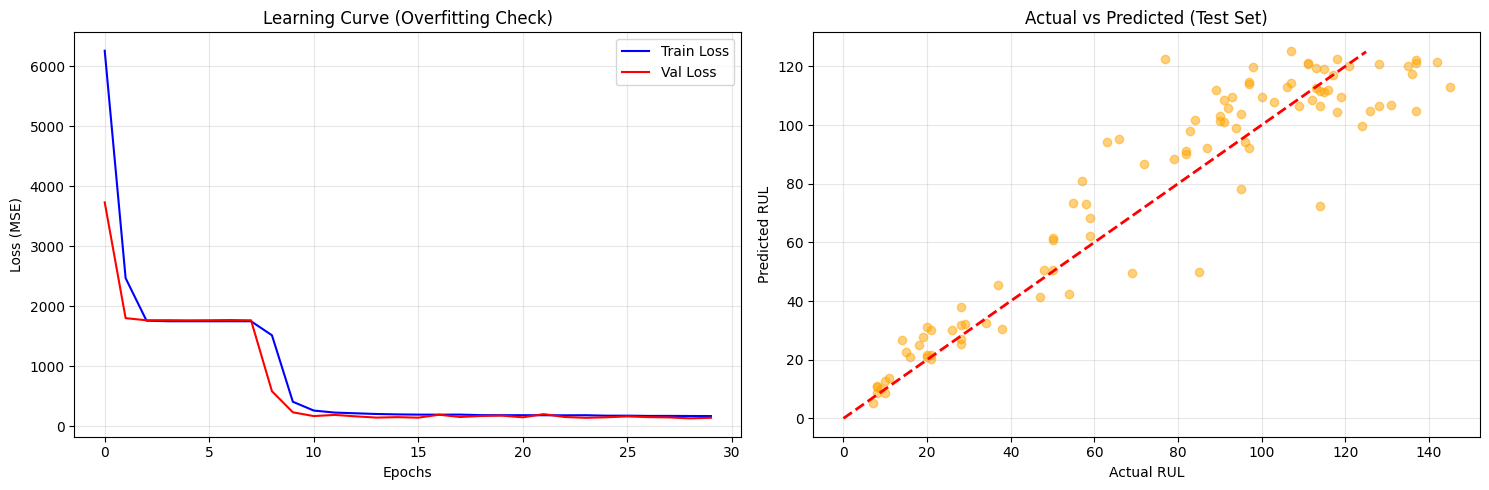

In [132]:
# [STEP 3] 모델 생성 및 학습 (업데이트된 함수 사용)
model_lstm = LSTMModel(input_size=len(selected_sensors), hidden_size=hidden_size, num_layers=num_layers)

# 학습 진행하며 history 받아오기
model_lstm, history = train_pytorch_lstm(
    model_lstm, tr_loader, val_loader, 
    epochs=n_epochs, lr=learning_rate
)

# [STEP 4] 시각화 검증 (과적합 체크!)
import matplotlib.pyplot as plt

def verify_model(history, y_test, preds):
    plt.figure(figsize=(15, 5))
    
    # (1) Loss Curve: 과적합 확인용
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='red')
    plt.title('Learning Curve (Overfitting Check)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # (2) 실제값 vs 예측값 분포 (Test Set)
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, preds, alpha=0.5, color='orange')
    plt.plot([0, 125], [0, 125], 'r--', lw=2) # 대각선(정답선)
    plt.title('Actual vs Predicted (Test Set)')
    plt.xlabel('Actual RUL')
    plt.ylabel('Predicted RUL')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 최종 보고서 출력 전 실행
model_lstm.eval()
with torch.no_grad():
    lstm_test_preds = model_lstm(t_te_x).numpy().flatten()

# 검증 그래프 출력! ㅋ
verify_model(history, y_test, lstm_test_preds)

# (기존 결과 보고서 출력 로직 생략...)

# Transformer

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import math
from torch.utils.data import DataLoader, TensorDataset

# [모델] Time-series Transformer
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super(TransformerModel, self).__init__()
        # 입력 차원을 d_model 차원으로 임베딩
        self.embedding = nn.Linear(input_dim, d_model)
        
        # 위치 정보 추가 (Positional Encoding)
        self.pos_encoder = nn.Parameter(torch.zeros(1, 100, d_model)) 
        
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (Batch, Feature, Window) -> (Batch, Window, Feature)
        x = x.transpose(1, 2)
        x = self.embedding(x)
        x = x + self.pos_encoder[:, :x.size(1), :]
        
        x = self.transformer_encoder(x)
        # 마지막 시점(Last Time-step)의 출력만 사용
        x = self.decoder(x[:, -1, :])
        return x

# [학습 함수]
def train_pytorch_transformer(model, tr_loader, val_loader, epochs=50, lr=0.0005):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    print(f" Transformer 학습 시작 (ID 격리, LR: {lr}, Epochs: {epochs})")
    for epoch in range(epochs):
        model.train()
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
        
        if (epoch+1) % 10 == 0:
            model.eval()
            v_loss = 0
            with torch.no_grad():
                for vx, vy in val_loader:
                    v_loss += criterion(model(vx), vy).item()
            print(f"Epoch [{epoch+1}/{epochs}] Val RMSE: {np.sqrt(v_loss/len(val_loader)):.4f}")
            
    return model

In [128]:
# ──────────────────────────────────────────────────────────
# 실행부: 모든 변수 설정 (Transformer 버전)
# ──────────────────────────────────────────────────────────
# 1. 데이터 전처리 관련 변수
exclude_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19', 's_9']
sigma = 2.0 
norm_method = 'minmax' 
rul_cap = 125 
window_size = 30 
val_size = 0.2 

# 2. Transformer 하이퍼파라미터
n_epochs = 30          # 트랜스포머는 수렴이 빠르니 50회만 먼저!
learning_rate = 0.0005 
batch_size = 64
d_model = 64           # 내부 임베딩 차원
nhead = 4              # Attention Head 개수
num_layers = 2         # Encoder 레이어 수

# [STEP 1] 데이터셋 빌드
X_train, X_val, X_test, y_train, y_val, y_test, selected_sensors = build_dataset(
    df_train=df_train, df_test=df_test, df_rul=df_rul,
    exclude_sensors=exclude_sensors, sigma=sigma, norm_method=norm_method,
    rul_cap=rul_cap, window_size=window_size, val_size=val_size
)

# [STEP 2] 텐서 변환 및 데이터로더 설정
t_tr_x, t_tr_y, t_val_x, t_val_y, t_te_x, t_te_y = prepare_torch_data(
    X_train, X_val, X_test, y_train, y_val, y_test, window_size=window_size
)

tr_loader = DataLoader(TensorDataset(t_tr_x, t_tr_y), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(t_val_x, t_val_y), batch_size=batch_size)

# [STEP 3] 모델 생성 및 학습
model_tf = TransformerModel(
    input_dim=len(selected_sensors),
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers
)

model_tf = train_pytorch_transformer(
    model_tf, tr_loader, val_loader, 
    epochs=n_epochs, lr=learning_rate
)

# [STEP 4] 최종 보고서 출력
model_tf.eval()
with torch.no_grad():
    tf_val_preds = model_tf(t_val_x).numpy().flatten()
    tf_test_preds = model_tf(t_te_x).numpy().flatten()

print("\n" + "="*65)
print(f"[Transformer 최종 결과 보고서 - ID 격리 적용]")
print("-" * 65)
print(f" [1] 내부 검증(Validation) 결과")
print(f"     - RMSE  : {rmse(y_val, tf_val_preds):.4f}")
print(f"     - SCORE : {score(y_val, tf_val_preds):.2f}")
print("-" * 65)
print(f" [2] 최종 실전(Final Test) 결과")
print(f"     - RMSE  : {rmse(y_test, tf_test_preds):.4f}")
print(f"     - SCORE : {score(y_test, tf_test_preds):.2f}")
print("="*65)

[select_sensors] 선택된 센서 수: 13 | 제외: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19', 's_9']
[remove_noise] gaussian sigma=2.0 적용 완료
[normalize] method=minmax 적용 완료
[create_rul_label] RUL cap=125 | RUL range: 0 ~ 125
[create_windows] train window X=(14241, 390) | y=(14241,)
[create_windows] train window X=(3490, 390) | y=(3490,)
[create_windows_test] test window X=(100, 390) | y=(100,)

[build_dataset] 완료 (ID: unit_nr 격리 성공)
  - Train 엔진: 80개, Val 엔진: 20개
  - X_train=(14241, 390) | X_val=(3490, 390) | X_test=(100, 390)
🚀 Transformer 학습 시작 (ID 격리, LR: 0.0005, Epochs: 30)
Epoch [10/30] Val RMSE: 11.3778
Epoch [20/30] Val RMSE: 11.9152
Epoch [30/30] Val RMSE: 12.0158

🔥 [Transformer 최종 결과 보고서 - ID 격리 적용]
-----------------------------------------------------------------
 [1] 내부 검증(Validation) 결과
     - RMSE  : 12.0402
     - SCORE : 11077.62
-----------------------------------------------------------------
 [2] 최종 실전(Final Test) 결과
     - RMSE  : 14.9166
     - SCORE : 404.52


In [130]:
import matplotlib.pyplot as plt

def plot_learning_curves(train_losses, val_losses, title="Model Learning Curve"):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss (MSE)')
    plt.plot(val_losses, label='Val Loss (MSE)')
    
    # 최적의 지점 표시 (Val Loss가 가장 낮은 지점)
    min_val_idx = np.argmin(val_losses)
    plt.axvline(min_val_idx, color='r', linestyle='--', label=f'Best Epoch ({min_val_idx})')
    
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# 💡 사용법: 
# 학습 함수(train_pytorch_...)에서 리스트로 담아둔 loss 기록을 넣으세요.
plot_learning_curves(history['train_loss'], history['val_loss'], title="LSTM Training Result")

NameError: name 'history' is not defined